# Notebook 07 — Agricultural Statistics

Derives agriculture statistics from post-segmentation and FCover outputs.

**Statistics computed:**
1. Crop type area and proportion per SA (hectares)
2. Crop diversity index (Shannon H) per SA
3. FCover statistics per class per SA (mean, SD, min, max)
4. Grass / forage area and availability index per SA
5. Farming system classification per SA
6. Cultivation intensity per SA
7. Consolidated summary table

**Data sources used:**
- Label rasters (all 19 SAs) — for in-sample landscape statistics
- Prediction rasters (3 test SAs only) — for unbiased predictions
- Enumerator data

**All outputs saved to:** `AgriStats/`

## Cell 0. Configuration

In [1]:
# ── Configuration ────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import ast, warnings
warnings.filterwarnings("ignore")

BASE_DIR  = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
PRED_DIR  = BASE_DIR / "Predictions"
SA_ROOT   = BASE_DIR
LABEL_DIR = BASE_DIR / "Labels"

# All 19 SA IDs
ALL_SAS = [
    "9545448","9805753","9965805","10085703","10125706",
    "10145814","10165835","10165859","10185850","10305790",
    "10445787","10565691","10595716","10605304","10765685",
    "10865406","10865805","11125706","11226291",
]

TEST_SAS = ["10125706","10605304","10865805"]

# Split assignment for reference
SPLIT_MAP = {
    "11226291":"train","9965805":"train","9805753":"train",
    "10565691":"train","10305790":"train","10865406":"train",
    "10165835":"train","10085703":"train","10185850":"train",
    "9545448":"train","10445787":"train","11125706":"train",
    "10165859":"train","10145814":"val","10595716":"val",
    "10765685":"val","10125706":"test","10605304":"test",
    "10865805":"test",
}

CLASS_NAMES = [
    "Maize","Maize+Pumpkin","Beans+Maize",
    "Cassava+Maize","Grass","Mixed",
]
CROP_CLASSES = [0,1,2,3,5]   # excludes Grass (4)
GRASS_IDX    = 4
IGNORE_INDEX = 255

CLASS_COLORS = [
    (1.00,0.85,0.00),(1.00,0.55,0.00),(0.20,0.63,0.17),
    (0.65,0.16,0.16),(0.13,0.55,0.13),(0.50,0.50,0.50),
]
CMAP = ListedColormap(CLASS_COLORS)

STATS_DIR = BASE_DIR / "AgriStats"
STATS_DIR.mkdir(exist_ok=True)

print("Config ready.")
print(f"SAs for analysis : {len(ALL_SAS)} total  |  {len(TEST_SAS)} test")
print(f"Output dir       : {STATS_DIR}")

Config ready.
SAs for analysis : 19 total  |  3 test
Output dir       : E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats


## Cell 1. Helper functions

In [2]:
# ── Pixel resolution helper ───────────────────────────────────────────────
# Reads pixel size from the prediction raster to compute areas.
# UAV imagery 5 cm GSD. 

def get_pixel_area_m2(raster_path):
    """Return pixel area in m² from raster geotransform."""
    with rasterio.open(raster_path) as src:
        res = src.res   # (pixel_width, pixel_height) in CRS units
    return abs(res[0] * res[1])   # m² assuming projected CRS


def get_sa_dir(base_dir, sa_id):
    for d in base_dir.iterdir():
        if d.is_dir() and d.name.endswith(sa_id):
            return d
    return None


def find_pred(sa_id, modality):
    """Find prediction raster for a given SA and modality."""
    mod_short = "rgb" if modality == "rgb" else "ms"
    dir_name  = "rgb_v3" if modality == "rgb" else "ms_v1"
    path = PRED_DIR / dir_name / f"{sa_id}_pred_{mod_short}.tif"
    return path if path.exists() else None


def find_label(sa_id):
    """Find label raster for a given SA."""
    path = LABEL_DIR / f"{sa_id}_labels.tif"
    return path if path.exists() else None


print("Helpers defined.")

Helpers defined.


## Cell 2. Crop type area and proportion per SA

Computes hectares and percentage per crop class per SA.


In [3]:
# ── STATISTIC 1: Crop type area and proportion per SA ────────────────────
# Pixel count × pixel area → hectares per class per SA.
.

rows = []
for sa_id in ALL_SAS:
    split    = SPLIT_MAP.get(sa_id, "unknown")
    # Use prediction raster for test SAs, label raster for others
    if split == "test":
        pred_rgb = find_pred(sa_id, "rgb")
        pred_ms  = find_pred(sa_id, "ms")
        sources  = [("rgb_pred", pred_rgb), ("ms_pred", pred_ms)]
    else:
        lbl = find_label(sa_id)
        sources = [("label", lbl)]

    for src_name, rpath in sources:
        if rpath is None or not rpath.exists():
            continue

        px_area = get_pixel_area_m2(rpath)

        with rasterio.open(rpath) as src:
            data = src.read(1).ravel()

        valid   = data[data != IGNORE_INDEX]
        total_px = len(valid)
        if total_px == 0:
            continue

        total_ha = total_px * px_area / 10_000
        row = {
            "SA":       sa_id,
            "split":    split,
            "source":   src_name,
            "total_valid_ha": round(total_ha, 4),
        }

        for i, name in enumerate(CLASS_NAMES):
            count = int(np.sum(valid == i))
            ha    = count * px_area / 10_000
            pct   = count / total_px * 100
            row[f"{name}_ha"]  = round(ha, 4)
            row[f"{name}_pct"] = round(pct, 2)

        crop_px  = int(np.sum(np.isin(valid, CROP_CLASSES)))
        grass_px = int(np.sum(valid == GRASS_IDX))
        row["total_crop_ha"]   = round(crop_px  * px_area / 10_000, 4)
        row["total_grass_ha"]  = round(grass_px * px_area / 10_000, 4)
        row["crop_intensity_pct"] = round(crop_px / total_px * 100, 2)
        rows.append(row)

area_df = pd.DataFrame(rows)
area_df.to_csv(STATS_DIR / "crop_area_per_sa.csv", index=False)
print(f"Saved -> {STATS_DIR / 'crop_area_per_sa.csv'}")
print(f"\nCrop area summary (test SAs — prediction-based):")
test_area = area_df[area_df["split"]=="test"]
display(test_area[["SA","source","total_valid_ha","total_crop_ha",
                    "total_grass_ha","crop_intensity_pct"]].reset_index(drop=True))

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\crop_area_per_sa.csv

Crop area summary (test SAs — prediction-based):


,SA,source,total_valid_ha,total_crop_ha,total_grass_ha,crop_intensity_pct
0,10125706,rgb_pred,13.4043,9.2205,4.1838,68.79
1,10125706,ms_pred,13.4043,6.3669,7.0375,47.50
2,10605304,rgb_pred,17.7427,17.4564,0.2863,98.39
3,10605304,ms_pred,17.7427,17.7427,0.0000,100.00
4,10865805,rgb_pred,15.1820,13.5100,1.6720,88.99
5,10865805,ms_pred,15.1820,13.0876,2.0944,86.20


## Cell 3. Crop diversity index (Shannon H)

H = -sum(p × ln p) across crop classes.
Max H for 5 classes = 1.609. Evenness = H / ln(5).

In [4]:
# ── STATISTIC 2: Crop diversity index (Shannon H) per SA ─────────────────
# H = -sum(p * ln(p)) across crop classes only.
# Higher H = more diverse cropping system.
# Maximum H for 5 crop classes = ln(5) = 1.609

import math

def shannon_h(proportions):
    """Shannon diversity index. proportions is list/array summing to ~100."""
    h = 0.0
    total = sum(proportions)
    if total == 0:
        return 0.0
    for p in proportions:
        frac = p / total
        if frac > 0:
            h -= frac * math.log(frac)
    return round(h, 4)


div_rows = []
for _, row in area_df.iterrows():
    props = [row.get(f"{name}_pct", 0.0) for name in CLASS_NAMES
             if name != "Grass"]
    h = shannon_h(props)
    # Richness = number of crop classes with > 0.1% cover
    richness = sum(1 for p in props if p > 0.1)
    div_rows.append({
        "SA":           row["SA"],
        "split":        row["split"],
        "source":       row["source"],
        "Shannon_H":    h,
        "Max_H":        round(math.log(5), 4),
        "Evenness":     round(h / math.log(5), 4) if h > 0 else 0.0,
        "Crop_richness":richness,
    })

div_df = pd.DataFrame(div_rows)
div_df.to_csv(STATS_DIR / "crop_diversity_per_sa.csv", index=False)
print(f"Saved -> {STATS_DIR / 'crop_diversity_per_sa.csv'}")
print(f"\nCrop diversity index per SA:")
display(div_df[["SA","split","source","Shannon_H",
                "Evenness","Crop_richness"]].reset_index(drop=True))

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\crop_diversity_per_sa.csv

Crop diversity index per SA:


,SA,split,source,Shannon_H,Evenness,Crop_richness
0,9545448,train,label,0.9970,0.6195,5
1,9805753,train,label,0.4893,0.3040,3
2,9965805,train,label,0.4854,0.3016,2
3,10085703,train,label,0.1935,0.1202,2
4,10125706,test,rgb_pred,0.6801,0.4226,3
5,10125706,test,ms_pred,0.7054,0.4383,2
6,10145814,val,label,0.8838,0.5491,3
7,10165835,train,label,0.0000,0.0000,1
8,10165859,train,label,0.3768,0.2341,2
9,10185850,train,label,0.6422,0.3990,3


## Cell 4. FCover statistics per class per SA

Mean, SD, median, min, max FCover per crop class.
Requires crop_fcover_df from Notebook 06b.

In [5]:
# ── STATISTIC 3: FCover statistics per class per SA ──────────────────────
# Mean, SD, min, max, median FCover per class across segments within each SA.


try:
    _ = crop_fcover_df
    print("crop_fcover_df found in memory.")
except NameError:
    csv_path = BASE_DIR / "crop_only_fcover_results.csv"
    if csv_path.exists():
        crop_fcover_df = pd.read_csv(csv_path)
        print(f"Loaded crop_fcover_df from {csv_path}")
    else:
        raise RuntimeError(
            "crop_fcover_df not found. Run Notebook 06b first."
        )

fcover_cols = [c for c in crop_fcover_df.columns
               if c.startswith("crop_fcover_")]

stat_rows = []
for modality in ["rgb_v3","ms_v1"]:
    df_mod = crop_fcover_df[crop_fcover_df["modality"]==modality].copy()
    for sa_id in TEST_SAS:
        df_sa = df_mod[df_mod["sa_task"].astype(str)==sa_id]
        if df_sa.empty:
            continue
        row = {"SA": sa_id, "modality": modality,
               "n_segments": len(df_sa)}
        for col in fcover_cols:
            name = col.replace("crop_fcover_","").replace("_","+")
            vals = df_sa[col].dropna().values.astype(float)
            row[f"{name}_mean"]   = round(vals.mean(),  2)
            row[f"{name}_std"]    = round(vals.std(),   2)
            row[f"{name}_median"] = round(np.median(vals), 2)
            row[f"{name}_min"]    = round(vals.min(),   2)
            row[f"{name}_max"]    = round(vals.max(),   2)
        stat_rows.append(row)

fcover_stat_df = pd.DataFrame(stat_rows)
fcover_stat_df.to_csv(STATS_DIR / "fcover_stats_per_sa.csv", index=False)
print(f"Saved -> {STATS_DIR / 'fcover_stats_per_sa.csv'}")
print(f"\nFCover statistics (mean per class per SA):")
mean_cols = ["SA","modality","n_segments"] +             [c for c in fcover_stat_df.columns if c.endswith("_mean")]
display(fcover_stat_df[mean_cols].reset_index(drop=True))

Loaded crop_fcover_df from E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\crop_only_fcover_results.csv
Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\fcover_stats_per_sa.csv

FCover statistics (mean per class per SA):


,SA,modality,n_segments,Maize_mean,Maize+Pumpkin_mean,Beans+Maize_mean,Cassava+Maize_mean,Mixed_mean
0,10125706,rgb_v3,52,80.69,19.00,0.00,0.00,0.30
1,10605304,rgb_v3,35,89.44,0.00,6.68,0.00,3.88
2,10865805,rgb_v3,151,71.69,22.89,0.00,0.00,4.09
3,10125706,ms_v1,52,56.21,33.54,0.00,1.29,1.26
4,10605304,ms_v1,35,12.58,0.01,0.24,84.79,2.38
5,10865805,ms_v1,151,8.63,89.07,0.00,1.45,0.85


## Cell 5. Grass / forage statistics per SA

Grass area, grass-to-crop ratio, forage availability index.

> **Note:** Grass UA=0.91 — mapped grass is reliable.
> Grass PA=0.26 — estimates are conservative lower bounds.
> True grass extent is approximately 4× larger than mapped.

In [7]:
# ── STATISTIC 4: Grass / Forage statistics per SA ────────────────────────
# Grass area, grass-to-crop ratio, forage availability index.


forage_rows = []
for _, row in area_df.iterrows():
    crop_ha  = row["total_crop_ha"]
    grass_ha = row["total_grass_ha"]
    total_ha = row["total_valid_ha"]

    ratio = round(grass_ha / crop_ha, 4) if crop_ha > 0 else None
    grass_pct = round(grass_ha / total_ha * 100, 2) if total_ha > 0 else 0

    # Forage availability index (relative — not biomass)
    grass_fcover_mean = row.get("Grass_pct", 0.0)
    forage_idx = round(grass_ha * (grass_fcover_mean / 100), 4)

    forage_rows.append({
        "SA":                   row["SA"],
        "split":                row["split"],
        "source":               row["source"],
        "grass_area_ha":        round(grass_ha, 4),
        "crop_area_ha":         round(crop_ha, 4),
        "total_valid_ha":       round(total_ha, 4),
        "grass_pct_of_total":   grass_pct,
        "grass_to_crop_ratio":  ratio,
        "forage_index":         forage_idx,
        "note": ("Conservative — PA=0.26 means true grass extent "
                 "is ~4x larger than mapped")
    })

forage_df = pd.DataFrame(forage_rows)
forage_df.to_csv(STATS_DIR / "forage_stats_per_sa.csv", index=False)
print(f"Saved -> {STATS_DIR / 'forage_stats_per_sa.csv'}")
print(f"\nForage / Grass statistics per SA:")
display(forage_df[["SA","split","source","grass_area_ha",
                    "crop_area_ha","grass_pct_of_total",
                    "grass_to_crop_ratio"]].reset_index(drop=True))

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\forage_stats_per_sa.csv

Forage / Grass statistics per SA:


,SA,split,source,grass_area_ha,crop_area_ha,grass_pct_of_total,grass_to_crop_ratio
0,9545448,train,label,0.0000,13.4383,0.00,0.0000
1,9805753,train,label,0.0000,1.7846,0.00,0.0000
2,9965805,train,label,0.0000,0.5909,0.00,0.0000
3,10085703,train,label,0.0000,4.8791,0.00,0.0000
4,10125706,test,rgb_pred,4.1838,9.2205,31.21,0.4537
5,10125706,test,ms_pred,7.0375,6.3669,52.50,1.1053
6,10145814,val,label,6.8877,7.8013,46.89,0.8829
7,10165835,train,label,0.0000,3.0210,0.00,0.0000
8,10165859,train,label,0.0000,2.8463,0.00,0.0000
9,10185850,train,label,0.0000,4.0391,0.00,0.0000


## Cell 6. Farming system classification per SA

Classifies each SA into a farming system type based on crop proportions.
Cross-tabulates against enumerator farming_ty field.

In [8]:
# ── STATISTIC 5: Farming system classification per SA ────────────────────
# Classify each SA into a farming system type based on crop proportions.


def classify_farming_system(row):
    maize_pct = row.get("Maize_pct", 0)
    mp_pct    = row.get("Maize+Pumpkin_pct", 0)
    bm_pct    = row.get("Beans+Maize_pct", 0)
    cm_pct    = row.get("Cassava+Maize_pct", 0)
    mix_pct   = row.get("Mixed_pct", 0)
    crop_classes_present = sum([
        maize_pct > 2, mp_pct > 2, bm_pct > 2,
        cm_pct > 2, mix_pct > 2
    ])
    if maize_pct > 60:
        return "Maize monoculture dominant"
    elif bm_pct > 10 or cm_pct > 10:
        return "Mixed cereal-legume system"
    elif crop_classes_present >= 3:
        return "Diversified multi-crop system"
    elif mp_pct > 15:
        return "Maize-pumpkin intercrop system"
    else:
        return "Mixed / transitional"

area_df["farming_system"] = area_df.apply(classify_farming_system, axis=1)

# Load enumerator data for context only — farming_ty is uniform
try:
    enum_dir = BASE_DIR / "Enumerator_Data"
    xls_files = list(enum_dir.glob("Enumerator_Data.*"))
    spreadsheet = next(
        (f for f in xls_files if f.suffix.lower() in (".xls", ".xlsx")),
        None
    )
    if spreadsheet:
        engine = "openpyxl" if spreadsheet.suffix.lower() == ".xlsx" \
                 else "xlrd"
        df_enum = pd.read_excel(spreadsheet, engine=engine)
        df_enum["sa_task_str"] = (df_enum["sa_task"].astype(str)
                                  .str.strip()
                                  .str.replace(r"\.0$", "", regex=True))
        df_enum["newgid"] = df_enum["newgid"].astype(str).str.strip()

        # Check farming_ty distribution
        print("Enumerator farming_ty distribution:")
        print(df_enum["farming_ty"].value_counts().to_string())
        print()
        print("Note: farming_ty is uniform across all segments.")
        print("Farming system classification derived from crop proportions only.")
    else:
        print("No enumerator spreadsheet found — skipping df_enum load.")

except Exception as e:
    print(f"Could not load enumerator data: {e}")

# Save farming system classification
fs_df = area_df[["SA", "split", "source", "farming_system",
                  "Maize_pct", "Maize+Pumpkin_pct",
                  "Beans+Maize_pct", "Cassava+Maize_pct",
                  "Mixed_pct"]].copy()
fs_df.to_csv(STATS_DIR / "farming_system_classification.csv", index=False)
print(f"\nSaved -> {STATS_DIR / 'farming_system_classification.csv'}")
print(f"\nFarming system classification per SA:")
display(fs_df[["SA", "split", "farming_system",
               "Maize_pct", "Maize+Pumpkin_pct"]].reset_index(drop=True))

# Summary count of farming system types
print(f"\nFarming system distribution across all SAs (label-based):")
label_fs = fs_df[fs_df["source"] == "label"]
print(label_fs["farming_system"].value_counts().to_string())

Enumerator farming_ty distribution:
farming_ty
regular    1205

Note: farming_ty is uniform across all segments.
Farming system classification derived from crop proportions only.

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\farming_system_classification.csv

Farming system classification per SA:


,SA,split,farming_system,Maize_pct,Maize+Pumpkin_pct
0,9545448,train,Mixed cereal-legume system,7.78,3.90
1,9805753,train,Maize monoculture dominant,86.29,4.98
2,9965805,train,Maize monoculture dominant,81.06,0.00
3,10085703,train,Maize monoculture dominant,95.17,4.83
4,10125706,test,Maize-pumpkin intercrop system,43.41,25.11
5,10125706,test,Maize-pumpkin intercrop system,25.58,21.80
6,10145814,val,Diversified multi-crop system,34.77,9.03
7,10165835,train,Maize monoculture dominant,100.00,0.00
8,10165859,train,Maize monoculture dominant,87.50,0.00
9,10185850,train,Maize monoculture dominant,79.10,14.43



Farming system distribution across all SAs (label-based):
farming_system
Maize monoculture dominant       8
Mixed cereal-legume system       3
Diversified multi-crop system    3
Mixed / transitional             2


## Cell 7. Cultivation intensity per SA

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\cultivation_intensity.csv


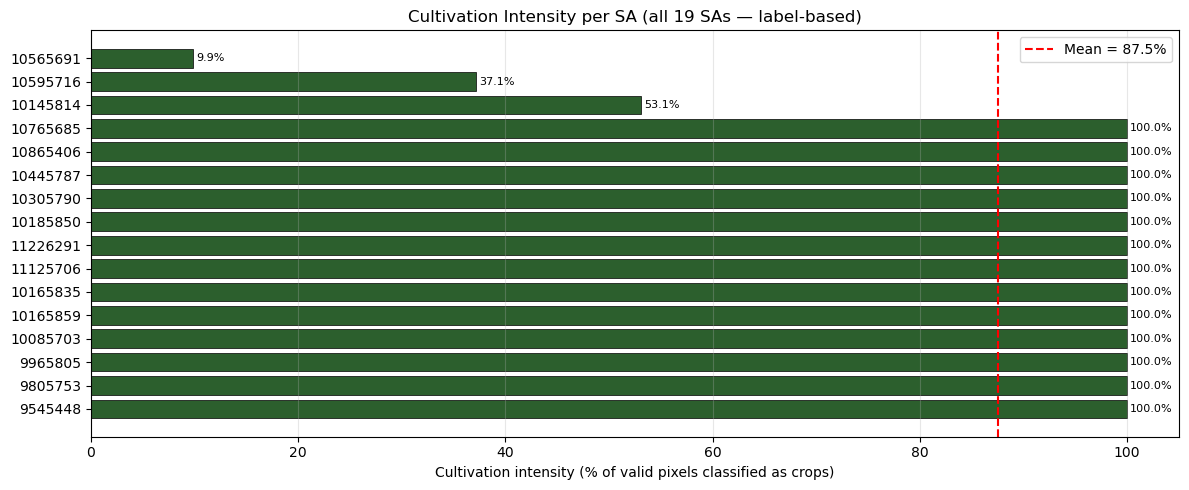

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\cultivation_intensity.png


In [10]:
# ── STATISTIC 6: Cultivation intensity by SA ─────────────────────────────
# Proportion of mapped area under active cultivation.
# High intensity = most vegetated pixels are crops.
# Low intensity = most vegetated pixels are grass / non-crop.

intensity_df = area_df[["SA","split","source",
                          "crop_intensity_pct",
                          "total_crop_ha",
                          "total_grass_ha",
                          "total_valid_ha"]].copy()
intensity_df = intensity_df.sort_values("crop_intensity_pct",
                                         ascending=False)
intensity_df.to_csv(STATS_DIR / "cultivation_intensity.csv", index=False)
print(f"Saved -> {STATS_DIR / 'cultivation_intensity.csv'}")

fig, ax = plt.subplots(figsize=(12, 5))
# Plot only label-based stats for all SAs
plot_df = intensity_df[intensity_df["source"]=="label"].copy()
bars = ax.barh(plot_df["SA"], plot_df["crop_intensity_pct"],
               color="#2C5F2D", edgecolor="black", linewidth=0.5)
ax.axvline(plot_df["crop_intensity_pct"].mean(),
           color="red", linestyle="--", linewidth=1.5,
           label=f"Mean = {plot_df['crop_intensity_pct'].mean():.1f}%")
ax.set_xlabel("Cultivation intensity (% of valid pixels classified as crops)")
ax.set_title("Cultivation Intensity per SA (all 19 SAs — label-based)")
ax.legend(); ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, plot_df["crop_intensity_pct"]):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(STATS_DIR / "cultivation_intensity.png", dpi=150)
plt.show()
print(f"Saved -> {STATS_DIR / 'cultivation_intensity.png'}")

## Cell 8. Consolidated summary statistics table

In [11]:
# ── STATISTIC 7: Summary agricultural statistics table ────────────────────
# One consolidated table for thesis reporting.

print("=" * 70)
print("CONSOLIDATED AGRICULTURAL STATISTICS SUMMARY")
print("=" * 70)

# Use label-based for all SAs, prediction-based for test SAs
label_stats = area_df[area_df["source"]=="label"]
pred_rgb    = area_df[area_df["source"]=="rgb_pred"]
pred_ms     = area_df[area_df["source"]=="ms_pred"]

print(f"\nStudy area coverage ({len(ALL_SAS)} SAs):")
print(f"  Total mapped area        : "
      f"{label_stats['total_valid_ha'].sum():.2f} ha")
print(f"  Total cultivated area    : "
      f"{label_stats['total_crop_ha'].sum():.2f} ha  "
      f"({label_stats['crop_intensity_pct'].mean():.1f}% mean intensity)")
print(f"  Total grass/forage area  : "
      f"{label_stats['total_grass_ha'].sum():.2f} ha  "
      f"(conservative — Grass PA=0.26)")

print(f"\nCrop type distribution (mean % across all SAs):")
for name in CLASS_NAMES:
    col = f"{name}_pct"
    if col in label_stats.columns:
        print(f"  {name:20s}: {label_stats[col].mean():.2f}%  "
              f"(SD={label_stats[col].std():.2f}%)")

print(f"\nCrop diversity (Shannon H, label-based):")
div_label = div_df[div_df["source"]=="label"]
print(f"  Mean Shannon H           : "
      f"{div_label['Shannon_H'].mean():.4f}")
print(f"  Range                    : "
      f"{div_label['Shannon_H'].min():.4f} – "
      f"{div_label['Shannon_H'].max():.4f}")
print(f"  Mean crop richness       : "
      f"{div_label['Crop_richness'].mean():.1f} classes per SA")

print(f"\nForage / grass (label-based):")
forage_label = forage_df[forage_df["source"]=="label"]
print(f"  Mean grass area per SA   : "
      f"{forage_label['grass_area_ha'].mean():.2f} ha")
print(f"  Mean grass:crop ratio    : "
      f"{forage_label['grass_to_crop_ratio'].mean():.3f}")
print(f"  Note: True grass extent estimated ~4x larger due to "
      f"Grass PA=0.26")

print(f"\n{'='*70}")

# Save consolidated summary
summary = {
    "total_mapped_ha":       round(label_stats["total_valid_ha"].sum(),2),
    "total_cultivated_ha":   round(label_stats["total_crop_ha"].sum(),2),
    "mean_crop_intensity":   round(label_stats["crop_intensity_pct"].mean(),2),
    "total_grass_ha_mapped": round(label_stats["total_grass_ha"].sum(),2),
    "mean_shannon_H":        round(div_label["Shannon_H"].mean(),4),
    "mean_crop_richness":    round(div_label["Crop_richness"].mean(),1),
    "mean_grass_crop_ratio": round(forage_label["grass_to_crop_ratio"].mean(),3),
    "n_SAs":                 len(ALL_SAS),
}
pd.DataFrame([summary]).to_csv(
    STATS_DIR / "agri_stats_summary.csv", index=False)
print(f"Saved -> {STATS_DIR / 'agri_stats_summary.csv'}")

CONSOLIDATED AGRICULTURAL STATISTICS SUMMARY

Study area coverage (19 SAs):
  Total mapped area        : 122.91 ha
  Total cultivated area    : 89.39 ha  (87.5% mean intensity)
  Total grass/forage area  : 33.52 ha  (conservative — Grass PA=0.26)

Crop type distribution (mean % across all SAs):
  Maize               : 56.30%  (SD=35.97%)
  Maize+Pumpkin       : 4.87%  (SD=5.24%)
  Beans+Maize         : 5.74%  (SD=14.57%)
  Cassava+Maize       : 0.90%  (SD=2.16%)
  Grass               : 12.49%  (SD=28.02%)
  Mixed               : 19.69%  (SD=27.75%)

Crop diversity (Shannon H, label-based):
  Mean Shannon H           : 0.5567
  Range                    : 0.0000 – 1.2045
  Mean crop richness       : 2.8 classes per SA

Forage / grass (label-based):
  Mean grass area per SA   : 2.09 ha
  Mean grass:crop ratio    : 0.731
  Note: True grass extent estimated ~4x larger due to Grass PA=0.26

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\agri_stats_summary.csv


## Cell 9. Crop composition stacked bar chart — all 19 SAs

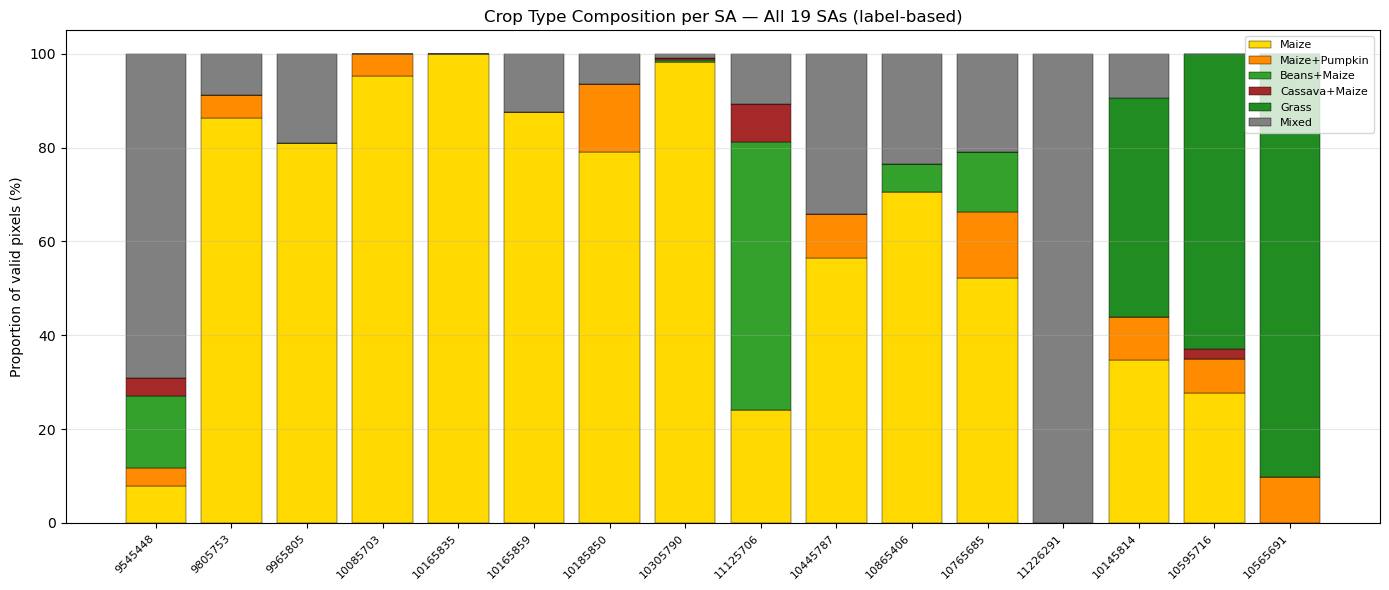

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\crop_composition_all_sas.png


In [12]:
# ── VISUALISATION: Crop area composition per SA ───────────────────────────
label_stats = area_df[area_df["source"]=="label"].copy()
label_stats = label_stats.sort_values("crop_intensity_pct", ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(label_stats))
x     = np.arange(len(label_stats))

for i, name in enumerate(CLASS_NAMES):
    col  = f"{name}_pct"
    vals = label_stats[col].values if col in label_stats.columns            else np.zeros(len(label_stats))
    ax.bar(x, vals, bottom=bottom, color=CLASS_COLORS[i],
           edgecolor="black", linewidth=0.3, label=name)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(label_stats["SA"].values, rotation=45, ha="right",
                   fontsize=8)
ax.set_ylabel("Proportion of valid pixels (%)")
ax.set_title("Crop Type Composition per SA — All 19 SAs (label-based)")
ax.legend(loc="upper right", fontsize=8, frameon=True)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(STATS_DIR / "crop_composition_all_sas.png", dpi=150)
plt.show()
print(f"Saved -> {STATS_DIR / 'crop_composition_all_sas.png'}")

## Cell 10. Shannon diversity visualisation

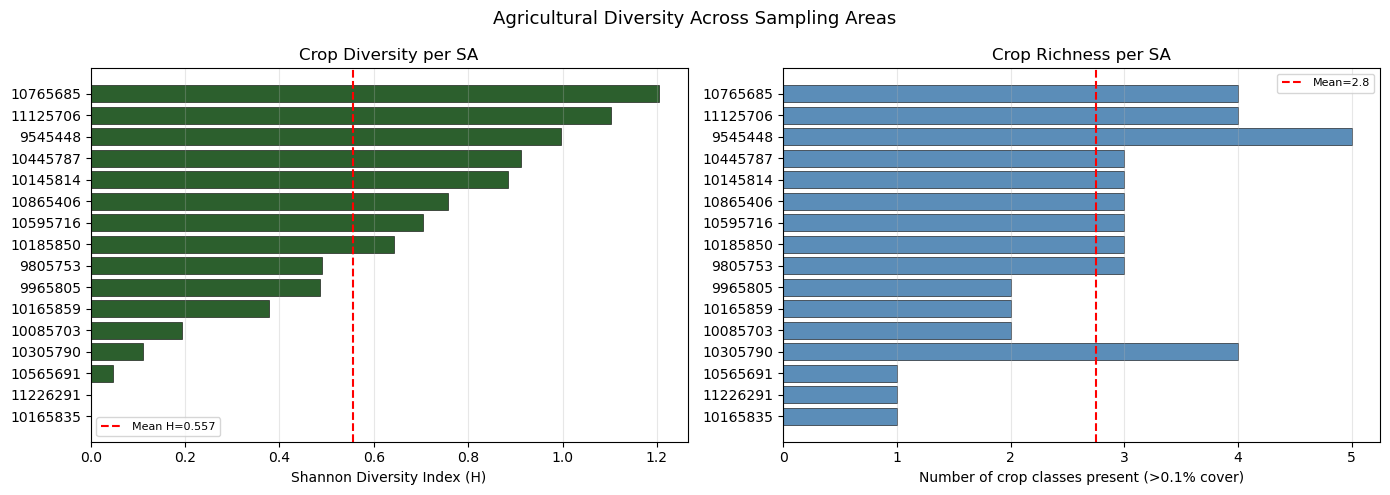

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\crop_diversity_all_sas.png


In [13]:
# ── VISUALISATION: Shannon diversity map ─────────────────────────────────
div_label = div_df[div_df["source"]=="label"].copy()
div_label = div_label.sort_values("Shannon_H", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of Shannon H per SA
axes[0].barh(div_label["SA"], div_label["Shannon_H"],
             color="#2C5F2D", edgecolor="black", linewidth=0.4)
axes[0].axvline(div_label["Shannon_H"].mean(),
                color="red", linestyle="--", linewidth=1.5,
                label=f"Mean H={div_label['Shannon_H'].mean():.3f}")
axes[0].set_xlabel("Shannon Diversity Index (H)")
axes[0].set_title("Crop Diversity per SA")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", alpha=0.3)

# Crop richness bar chart
axes[1].barh(div_label["SA"], div_label["Crop_richness"],
             color="#5B8DB8", edgecolor="black", linewidth=0.4)
axes[1].axvline(div_label["Crop_richness"].mean(),
                color="red", linestyle="--", linewidth=1.5,
                label=f"Mean={div_label['Crop_richness'].mean():.1f}")
axes[1].set_xlabel("Number of crop classes present (>0.1% cover)")
axes[1].set_title("Crop Richness per SA")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Agricultural Diversity Across Sampling Areas",
             fontsize=13)
plt.tight_layout()
plt.savefig(STATS_DIR / "crop_diversity_all_sas.png", dpi=150)
plt.show()
print(f"Saved -> {STATS_DIR / 'crop_diversity_all_sas.png'}")

## Cell 11. Grass vs crop area visualisation

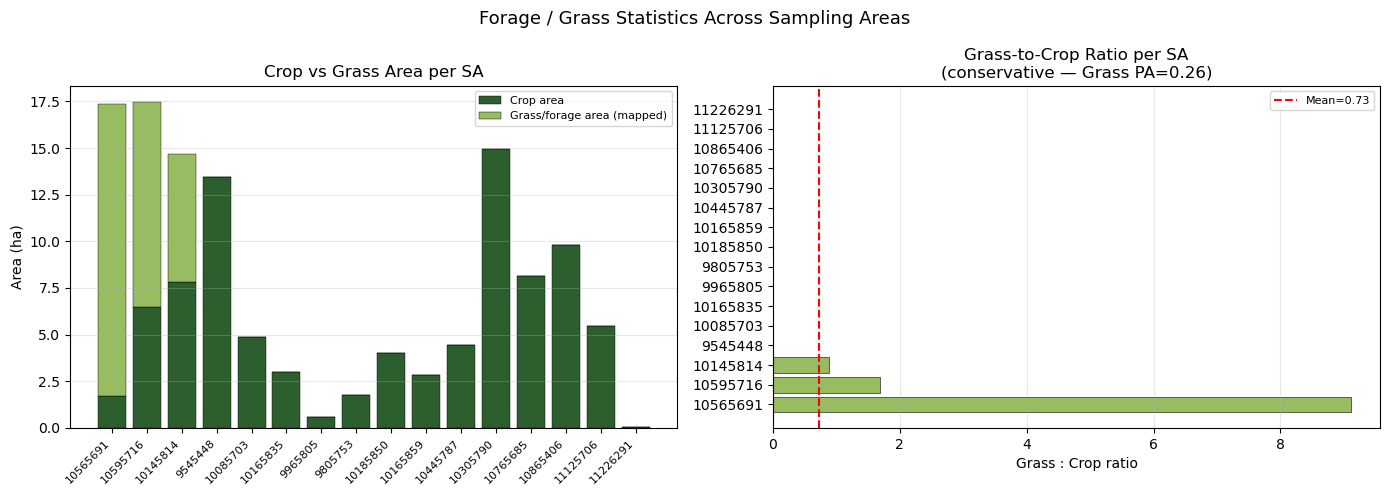

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\forage_stats_all_sas.png


In [14]:
# ── VISUALISATION: Grass vs crop area per SA ──────────────────────────────
forage_label = forage_df[forage_df["source"]=="label"].copy()
forage_label = forage_label.sort_values("grass_to_crop_ratio",
                                         ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: crop vs grass area
x = np.arange(len(forage_label))
axes[0].bar(x, forage_label["crop_area_ha"], label="Crop area",
            color="#2C5F2D", edgecolor="black", linewidth=0.3)
axes[0].bar(x, forage_label["grass_area_ha"],
            bottom=forage_label["crop_area_ha"],
            label="Grass/forage area (mapped)",
            color="#97BC62", edgecolor="black", linewidth=0.3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(forage_label["SA"].values,
                         rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Area (ha)")
axes[0].set_title("Crop vs Grass Area per SA")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Grass-to-crop ratio
axes[1].barh(forage_label["SA"],
             forage_label["grass_to_crop_ratio"],
             color="#97BC62", edgecolor="black", linewidth=0.4)
axes[1].axvline(forage_label["grass_to_crop_ratio"].mean(),
                color="red", linestyle="--", linewidth=1.5,
                label=f"Mean={forage_label['grass_to_crop_ratio'].mean():.2f}")
axes[1].set_xlabel("Grass : Crop ratio")
axes[1].set_title("Grass-to-Crop Ratio per SA\n"
                   "(conservative — Grass PA=0.26)")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Forage / Grass Statistics Across Sampling Areas",
             fontsize=13)
plt.tight_layout()
plt.savefig(STATS_DIR / "forage_stats_all_sas.png", dpi=150)
plt.show()
print(f"Saved -> {STATS_DIR / 'forage_stats_all_sas.png'}")

## ADDITIONAL STATISTICS - Passing-Bablok


RGB — Passing-Bablok Regression
  Slope     : 0.0000  (95% CI: [-0.000, 0.000])
  Intercept : 100.0000  (95% CI: [100.000, 100.000])
  Slope CI excludes 1.0     : True
  Intercept CI excludes 0.0 : True
  OLS slope (comparison)    : 0.0108

MS — Passing-Bablok Regression
  Slope     : 0.0000  (95% CI: [0.000, 0.000])
  Intercept : 100.0000  (95% CI: [100.000, 100.000])
  Slope CI excludes 1.0     : True
  Intercept CI excludes 0.0 : True
  OLS slope (comparison)    : 0.0971

Saved -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\passing_bablok_fcover.png


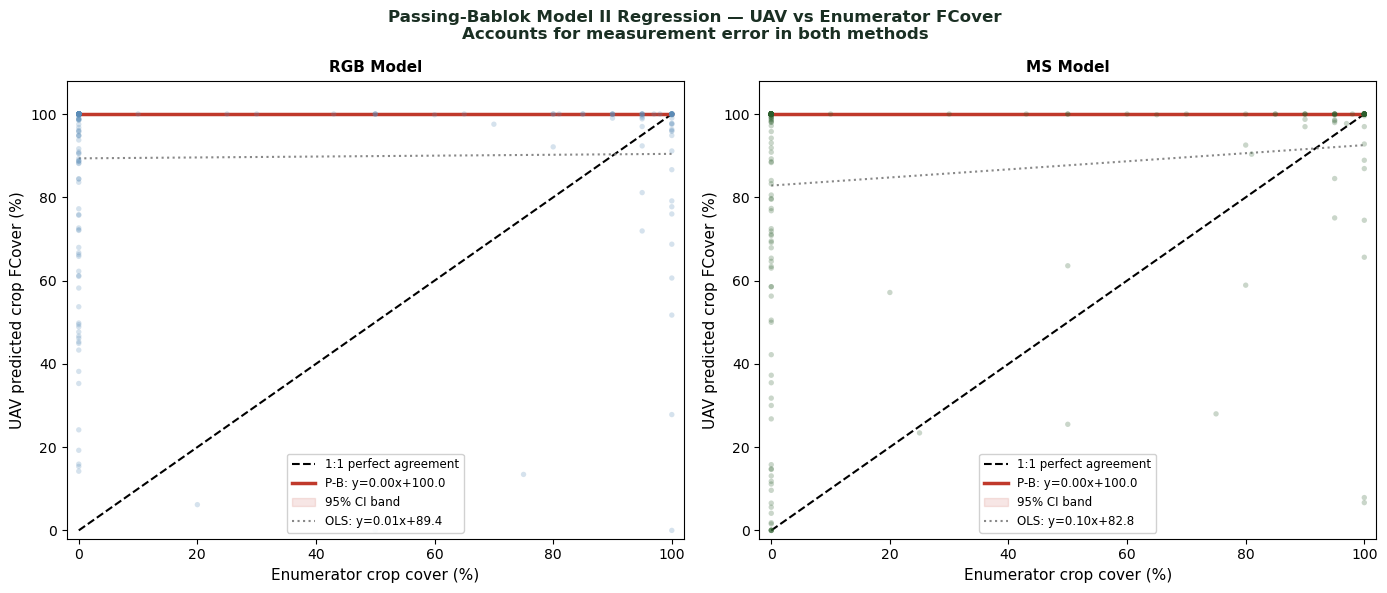

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE_DIR  = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
fcover_df = pd.read_csv(BASE_DIR / "segment_fcover_results.csv")

crop_cols = [c for c in fcover_df.columns
             if c.startswith("pred_fcover_") and "Grass" not in c]
fcover_df["pred_total_crop"] = fcover_df[crop_cols].sum(axis=1)
fcover_df["crop_cov_1"]      = pd.to_numeric(
    fcover_df["crop_cov_1"], errors="coerce")

# ── Passing-Bablok implementation (no external package needed) ────
def passing_bablok(x, y, alpha=0.05):
    """
    Passing-Bablok Model II regression.
    Returns slope, intercept and their 95% confidence intervals.
    Reference: Passing & Bablok (1983), J Clin Chem Clin Biochem.
    """
    x, y = np.array(x, float), np.array(y, float)
    n    = len(x)

    # All pairwise slopes S_ij = (y_j - y_i) / (x_j - x_i)
    slopes = []
    for i in range(n):
        for j in range(i+1, n):
            dx = x[j] - x[i]
            dy = y[j] - y[i]
            if dx != 0:
                slopes.append(dy / dx)

    slopes = np.sort(slopes)
    m      = len(slopes)

    # Count slopes < -1 (shift index)
    K = int(np.sum(slopes < -1))

    # Median slope
    if m % 2 == 1:
        b = slopes[K + (m - 1) // 2]
    else:
        b = 0.5 * (slopes[K + m // 2 - 1] + slopes[K + m // 2])

    # Intercept
    a = np.median(y - b * x)

    # Confidence interval
    z   = stats.norm.ppf(1 - alpha / 2)
    C   = z * np.sqrt(n * (n - 1) * (2*n + 5) / 18)
    M1  = int(round((m - C) / 2))
    M2  = m - M1 + 1

    M1  = max(0, min(M1, m-1))
    M2  = max(0, min(M2, m-1))

    b_lo = slopes[K + M1]
    b_hi = slopes[K + M2]
    a_lo = np.median(y - b_hi * x)
    a_hi = np.median(y - b_lo * x)

    return {"slope":     b,    "slope_lo":  b_lo, "slope_hi":  b_hi,
            "intercept": a,    "int_lo":    a_lo, "int_hi":    a_hi}

# ── Run for both models ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="white")
fig.suptitle(
    "Passing-Bablok Model II Regression — UAV vs Enumerator FCover\n"
    "Accounts for measurement error in both methods",
    fontsize=12, fontweight="bold", color="#1A2F23")

for ax, (mod, color) in zip(axes, [("rgb","#5B8DB8"),("ms","#2C5F2D")]):
    df = fcover_df[
        fcover_df["modality"].str.contains(mod) &
        ~fcover_df["modality"].str.contains("unmask")
    ].dropna(subset=["crop_cov_1","pred_total_crop"]).copy()

    x = df["crop_cov_1"].values.astype(float)
    y = df["pred_total_crop"].values.astype(float)

    pb = passing_bablok(x, y)
    ols_slope, ols_int, *_ = stats.linregress(x, y)

    print(f"\n{mod.upper()} — Passing-Bablok Regression")
    print(f"  Slope     : {pb['slope']:.4f}  "
          f"(95% CI: [{pb['slope_lo']:.3f}, {pb['slope_hi']:.3f}])")
    print(f"  Intercept : {pb['intercept']:.4f}  "
          f"(95% CI: [{pb['int_lo']:.3f}, {pb['int_hi']:.3f}])")
    print(f"  Slope CI excludes 1.0     : "
          f"{not (pb['slope_lo'] <= 1.0 <= pb['slope_hi'])}")
    print(f"  Intercept CI excludes 0.0 : "
          f"{not (pb['int_lo']  <= 0.0 <= pb['int_hi'])}")
    print(f"  OLS slope (comparison)    : {ols_slope:.4f}")

    # Scatter
    ax.scatter(x, y, alpha=0.25, s=15, color=color,
               edgecolors="none", zorder=3)

    xs = np.linspace(0, 100, 200)

    # 1:1 line
    ax.plot([0,100],[0,100],"k--",lw=1.5,
            label="1:1 perfect agreement")

    # Passing-Bablok line + CI band
    y_pb = pb["slope"]*xs + pb["intercept"]
    y_lo = pb["slope_lo"]*xs + pb["int_lo"]
    y_hi = pb["slope_hi"]*xs + pb["int_hi"]
    ax.plot(xs, y_pb, color="#C0392B", lw=2.5,
            label=f"P-B: y={pb['slope']:.2f}x+{pb['intercept']:.1f}")
    ax.fill_between(xs, y_lo, y_hi,
                    color="#C0392B", alpha=0.12, zorder=2,
                    label="95% CI band")

    # OLS line for comparison
    ax.plot(xs, ols_slope*xs+ols_int, color="#888888",
            lw=1.5, linestyle=":",
            label=f"OLS: y={ols_slope:.2f}x+{ols_int:.1f}")

    ax.set_xlabel("Enumerator crop cover (%)", fontsize=11)
    ax.set_ylabel("UAV predicted crop FCover (%)", fontsize=11)
    ax.set_title(f"{mod.upper()} Model", fontsize=11, fontweight="bold")
    ax.set_xlim(-2, 102); ax.set_ylim(-2, 108)
    ax.legend(fontsize=8.5, framealpha=0.9)

plt.tight_layout()
save = BASE_DIR / "passing_bablok_fcover.png"
plt.savefig(save, dpi=150, bbox_inches="tight")
print(f"\nSaved -> {save}")
plt.show()